# Humanoid standup with plain MPPIv2 — hyperparameters only

Gets the G1 humanoid standup task to stand using the **stock `MPPIv2` controller and
the stock `G1StandupTask` cost** — no controller subclass, no extra cost terms, no
steering references. Unlike `humanoid_standup_feetref_mppi.ipynb` (which adds a feet
end-reference term and a rank-based selection rule), everything here is achieved by
choosing MPPIv2's constructor hyperparameters alone.

The humanoid is first collapsed to the ground by a scripted fold (zero control holds
the G1 upright, so the fold is needed to create a genuine standup problem), then plain
softmax MPPI plans against the unmodified standup cost (uprightness + torso height +
nominal pose) until the torso reaches the standing target.

**Working hyperparameters** (verified on seeds 0, 1, 2 — stands within ~2 s and holds
torso z ≈ 0.95 for the rest of the episode):

| hyperparameter | value | notes |
|---|---|---|
| `num_samples` | 256 | 128 also stands, but is slower to rise on some seeds |
| `noise_level` | 0.15 | sampling std around the mean knots |
| `temperature` | 0.05 | softmax sharpness over rollout scores |
| `num_knots` | 6 | spline knots over the plan horizon |
| `plan_horizon` | 0.8 s | 40 sim steps at dt = 0.02 |
| `spline_type` | `"cubic"` | smooth control interpolation between knots |
| `iterations` | 2 | resample/update passes per control step |
| `seed` | 0 | |

In [1]:
import numpy as np

from analytic_mppi.tasks.g1_standup import G1StandupTask
from analytic_mppi.dynamics import MujocoBackend
from analytic_mppi.controllers import MPPIv2

# ---- MPPIv2 hyperparameters (the only thing tuned in this notebook) ----
NUM_SAMPLES = 256
NOISE = 0.15
TEMP = 0.05
NUM_KNOTS = 6
PLAN_HORIZON = 0.8       # seconds
SPLINE = "cubic"
ITERATIONS = 2
SEED = 223

# ---- episode script ----
COLLAPSE_FOLD_T = 3.0    # scripted fold duration (s)
COLLAPSE_SETTLE_T = 2.0  # settle after releasing the fold (s)
T_MAX = 15.0             # standup budget (s)

## Collapse phase

Zero control holds the G1 upright (its position actuators target the `stand` pose), so
a scripted fold — hips and knees commanded into deep flexion for 3 s, then released —
drops it flat on the ground, from where zero control cannot recover. This is the
initial state the controller must stand up from.

In [2]:
task = G1StandupTask()
backend = MujocoBackend(task.model_path)

fold = np.zeros(backend.nu)
fold[[0, 6]] = -1.8      # hip pitch
fold[[3, 9]] = 2.6       # knees
fold[[4, 10]] = -0.6     # ankle pitch

collapse_states = []
n_fold = round(COLLAPSE_FOLD_T / backend.dt)
n_settle = round(COLLAPSE_SETTLE_T / backend.dt)
for step in range(n_fold + n_settle):
    backend.step(fold if step < n_fold else np.zeros(backend.nu))
    collapse_states.append(backend.get_state().copy())
state0 = backend.get_state().copy()

print(f"collapsed: pelvis z = {backend.data.qpos[2]:.3f}, "
      f"torso z = {backend.data.sensordata[task._torso_pos_adr + 2]:.3f}")

collapsed: pelvis z = 0.055, torso z = 0.013


## Standup run

Stock `MPPIv2` (softmax-weighted knot averaging) against the stock standup cost. The
controller sees only the unmodified `G1StandupTask` terms; success or failure is
entirely down to the hyperparameters above.

In [3]:
ctrl = MPPIv2(task=task, backend=backend, num_samples=NUM_SAMPLES,
              noise_level=NOISE, temperature=TEMP, num_knots=NUM_KNOTS,
              plan_horizon=PLAN_HORIZON, spline_type=SPLINE,
              iterations=ITERATIONS, seed=SEED)

backend.set_state(state0)
ctrl.reset()

stand_states = [backend.get_state().copy()]
torso_z_hist = [float(backend.data.sensordata[task._torso_pos_adr + 2])]
t_stood = None

T = round(T_MAX / backend.dt)
for step in range(T):
    u0 = ctrl.act(backend.get_state())
    backend.step(u0)

    stand_states.append(backend.get_state().copy())
    torso_z_hist.append(float(backend.data.sensordata[task._torso_pos_adr + 2]))

    t_now = (step + 1) * backend.dt
    if t_stood is None and torso_z_hist[-1] >= 0.85:
        t_stood = t_now
        print(f"t={t_now:5.2f}s  torso z reached {torso_z_hist[-1]:.2f} - standing")
    if step % 100 == 99:
        print(f"t={t_now:5.2f}s  torso z={torso_z_hist[-1]:.3f}")

print(f"\nfinal: torso z = {torso_z_hist[-1]:.3f} (target {task.target_height})")

t= 1.50s  torso z reached 0.85 - standing
t= 2.00s  torso z=0.905
t= 4.00s  torso z=0.966
t= 6.00s  torso z=0.956
t= 8.00s  torso z=0.958
t=10.00s  torso z=0.965
t=12.00s  torso z=0.957
t=14.00s  torso z=0.956

final: torso z = 0.952 (target 0.9)


## HTML render

The full episode — scripted collapse, then the MPPIv2 standup — as a self-contained
~30 s video.

In [4]:
import base64, os, tempfile

import imageio
import mujoco
from IPython.display import HTML, display

model = backend.model


def render_standup_html(states, *, width=480, height=320, stride=3, min_seconds=30.0):
    data = mujoco.MjData(model)
    qpos = states[:, 1:1 + model.nq]
    qvel = states[:, 1 + model.nq:1 + model.nq + model.nv]

    cam = mujoco.MjvCamera()
    mujoco.mjv_defaultFreeCamera(model, cam)
    cam.distance, cam.elevation, cam.azimuth = 3.0, -15.0, 135.0
    cam.lookat[:] = [qpos[-1, 0], qpos[-1, 1], 0.6]

    r = mujoco.Renderer(model, height=height, width=width)
    frames = []
    for qp, qv in zip(qpos[::stride], qvel[::stride]):
        data.qpos[:] = qp
        data.qvel[:] = qv
        mujoco.mj_forward(model, data)
        r.update_scene(data, cam)
        frames.append(r.render())
    r.close()

    fps = min(60.0, max(1.0, len(frames) / float(min_seconds)))
    with tempfile.NamedTemporaryFile(suffix=".mp4", delete=False) as f:
        path = f.name
    imageio.mimwrite(path, np.asarray(frames), fps=fps, codec="libx264")
    b64 = base64.b64encode(open(path, "rb").read()).decode()
    os.remove(path)
    return (f'<figure style="display:inline-block;text-align:center">'
            f'<figcaption><b>G1 standup with plain MPPIv2</b> &middot; '
            f'{len(frames) / fps:.0f}s (collapse, then standup)</figcaption>'
            f'<video controls autoplay loop muted width="{width}">'
            f'<source src="data:video/mp4;base64,{b64}" type="video/mp4">'
            f'</video></figure>')


all_states = np.asarray(collapse_states + stand_states)
display(HTML(render_standup_html(all_states)))

libdecor-gtk-WARNING: Failed to initialize GTK
Failed to load plugin 'libdecor-gtk.so': failed to init
No plugins found, falling back on no decorations



## Progress summary

Torso height over the whole episode. The gray span is the scripted collapse; after it,
plain MPPIv2 raises the torso to the target height and holds it there.

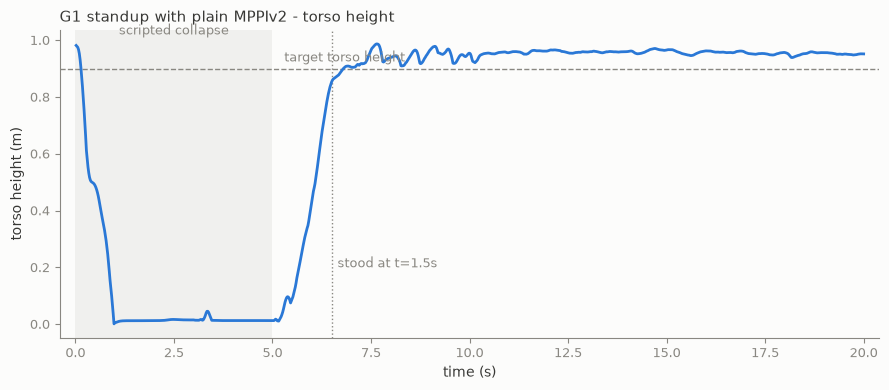

In [5]:
import matplotlib.pyplot as plt

INK, MUTED = "#383835", "#898781"
BLUE = "#2a78d6"
SURFACE = "#fcfcfb"

dt = backend.dt
t_collapse = np.arange(1, len(collapse_states) + 1) * dt
t_stand = t_collapse[-1] + np.arange(len(torso_z_hist)) * dt

# torso z during the collapse phase, read back from the recorded states
cq = np.asarray(collapse_states)[:, 1:1 + model.nq]
d_tmp = mujoco.MjData(model)
collapse_torso_z = []
for qp in cq:
    d_tmp.qpos[:] = qp
    mujoco.mj_forward(model, d_tmp)
    collapse_torso_z.append(float(d_tmp.sensordata[task._torso_pos_adr + 2]))

t_all = np.concatenate([t_collapse, t_stand])
torso_all = np.concatenate([collapse_torso_z, torso_z_hist])

fig, ax = plt.subplots(figsize=(9, 4), facecolor=SURFACE)
ax.set_facecolor(SURFACE)

ax.axvspan(0, t_collapse[-1], color=MUTED, alpha=0.10, lw=0)
ax.text(t_collapse[-1] / 2, 1.02, "scripted collapse", ha="center", color=MUTED, fontsize=9)
ax.axhline(task.target_height, color=MUTED, ls="--", lw=1)
ax.text(t_collapse[-1] + 0.3, task.target_height + 0.025, "target torso height",
        ha="left", color=MUTED, fontsize=9)
if t_stood is not None:
    ax.axvline(t_collapse[-1] + t_stood, color=MUTED, ls=":", lw=1)
    ax.text(t_collapse[-1] + t_stood + 0.15, 0.2, f"stood at t={t_stood:.1f}s",
            ha="left", color=MUTED, fontsize=9)

ax.plot(t_all, torso_all, color=BLUE, lw=2)

ax.set_xlabel("time (s)", color=INK)
ax.set_ylabel("torso height (m)", color=INK)
ax.set_title("G1 standup with plain MPPIv2 - torso height",
             color=INK, fontsize=11, loc="left")
for side in ("top", "right"):
    ax.spines[side].set_visible(False)
for side in ("left", "bottom"):
    ax.spines[side].set_color(MUTED)
ax.tick_params(colors=MUTED, labelsize=9)
ax.margins(x=0.02)
plt.tight_layout()
plt.show()